In [84]:
import numpy as np
import pandas as pd
import seaborn as sns


In [85]:
from sklearn.datasets import load_iris

iris =load_iris()

df = pd.DataFrame(iris.data,columns=iris.feature_names)
df['species']=iris.target

In [86]:
df.head(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [87]:
df = df.loc[df['species'] != 0 ,['sepal width (cm)','petal length (cm)','species']]

In [88]:
df.head(5)

,sepal width (cm),petal length (cm),species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


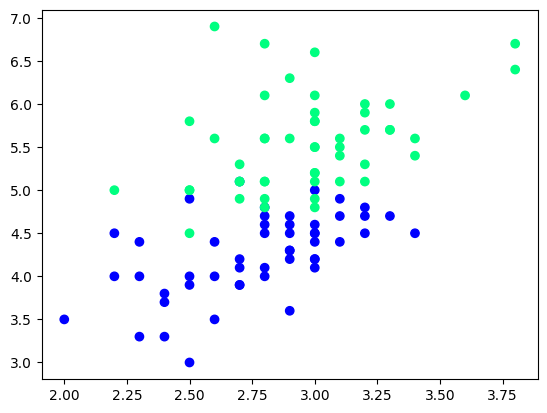

In [89]:
import matplotlib.pyplot as plt

plt.scatter(df['sepal width (cm)'],df['petal length (cm)'],c=df['species'],cmap='winter')

In [90]:
# Taking only 10 rows for training

df = df.sample(100)

df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [91]:
df_train

,sepal width (cm),petal length (cm),species
61,3.0,4.2,1
101,2.7,5.1,2
72,2.5,4.9,1
133,2.8,5.1,2
142,2.7,5.1,2
95,3.0,4.2,1
80,2.4,3.8,1
124,3.3,5.7,2
128,2.8,5.6,2
94,2.7,4.2,1


In [92]:
df_val

,sepal width (cm),petal length (cm),species
148,3.4,5.4,2
98,2.5,3.0,1
64,2.9,3.6,1
77,3.0,5.0,1
127,3.0,4.9,2


In [93]:
df_test

,sepal width (cm),petal length (cm),species
125,3.2,6.0,2
90,2.6,4.4,1
102,3.0,5.9,2
113,2.5,5.0,2
78,2.9,4.5,1


In [94]:
X_test =df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1]

In [95]:
X_test

array([[3.4, 5.4],
       [2.5, 3. ],
       [2.9, 3.6],
       [3. , 5. ],
       [3. , 4.9]])

In [96]:
y_test

148    2
98     1
64     1
77     1
127    2
Name: species, dtype: int64

### Case -1 Bagging

In [97]:
#data for Tree 1

df_bag = df_train.sample(8,replace=True)  # 8 means 10 ota row madhe 8 ota diyinxa ra replace=True means row duplication  i.e with replacement
df_bag

,sepal width (cm),petal length (cm),species
101,2.7,5.1,2
80,2.4,3.8,1
61,3.0,4.2,1
124,3.3,5.7,2
101,2.7,5.1,2
94,2.7,4.2,1
101,2.7,5.1,2
80,2.4,3.8,1


In [98]:
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

In [99]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [100]:
dt1 = DecisionTreeClassifier()

In [101]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values,y.values,clf=clf,legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test,y_pred))

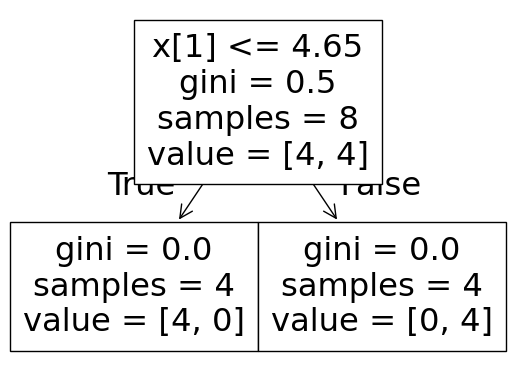

0.8


d:\FeatureEngineering\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
d:\FeatureEngineering\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


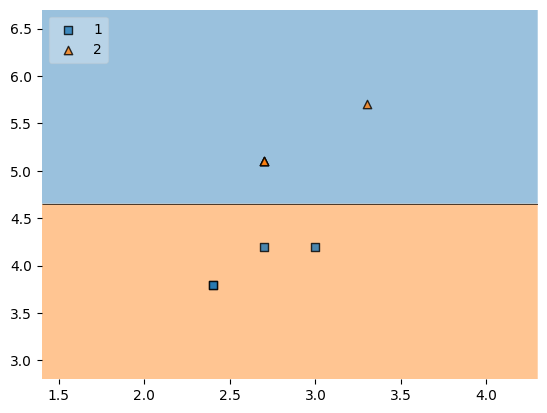

In [102]:
evaluate(dt1,X,y)

In [103]:
dt_bag2 = df_train.sample(8,replace=True)
dt_bag2

,sepal width (cm),petal length (cm),species
124,3.3,5.7,2
101,2.7,5.1,2
72,2.5,4.9,1
95,3.0,4.2,1
128,2.8,5.6,2
72,2.5,4.9,1
80,2.4,3.8,1
142,2.7,5.1,2


In [104]:
# fething X and y
X =dt_bag2.iloc[:,0:2]
y = dt_bag2.iloc[:,-1]

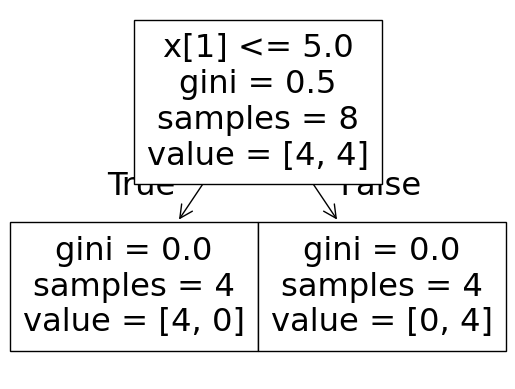

0.8


d:\FeatureEngineering\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
d:\FeatureEngineering\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


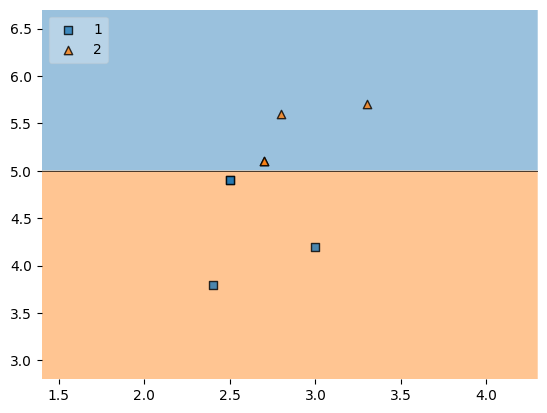

In [105]:
dt2 =DecisionTreeClassifier()
evaluate(dt2,X,y)

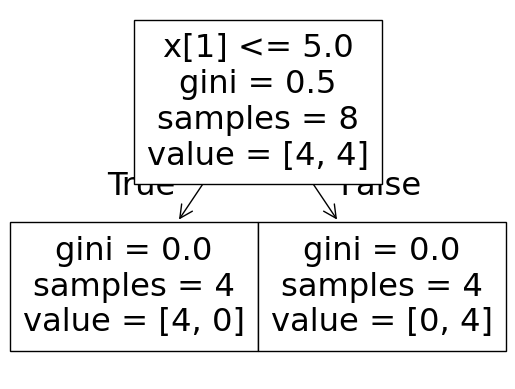

0.8


d:\FeatureEngineering\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
d:\FeatureEngineering\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


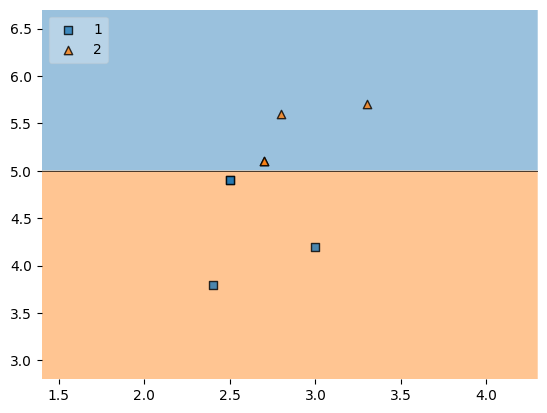

In [106]:
dt3 =DecisionTreeClassifier()
evaluate(dt3,X,y)

### Predicting

In [107]:
df_test

,sepal width (cm),petal length (cm),species
125,3.2,6.0,2
90,2.6,4.4,1
102,3.0,5.9,2
113,2.5,5.0,2
78,2.9,4.5,1


In [113]:
print("Predictor 1: ",dt1.predict(np.array([2.6,4.4]).reshape(1,2)))
print("Predictor 2: ",dt2.predict(np.array([2.6,4.4]).reshape(1,2)))
print("Predictor 3: ",dt3.predict(np.array([2.6,4.4]).reshape(1,2)))

Predictor 1:  [1]
Predictor 2:  [1]
Predictor 3:  [1]


d:\FeatureEngineering\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
d:\FeatureEngineering\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
d:\FeatureEngineering\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


### Pasting : row sampling without replacement

In [114]:
df_train

,sepal width (cm),petal length (cm),species
61,3.0,4.2,1
101,2.7,5.1,2
72,2.5,4.9,1
133,2.8,5.1,2
142,2.7,5.1,2
95,3.0,4.2,1
80,2.4,3.8,1
124,3.3,5.7,2
128,2.8,5.6,2
94,2.7,4.2,1


In [115]:
df_train.sample(8)

,sepal width (cm),petal length (cm),species
95,3.0,4.2,1
80,2.4,3.8,1
142,2.7,5.1,2
94,2.7,4.2,1
101,2.7,5.1,2
128,2.8,5.6,2
124,3.3,5.7,2
72,2.5,4.9,1


### Random Subspaces : column sampling with or without replacement

In [118]:
df.sample(2,replace=True,axis=1) # column sampling

,sepal width (cm),sepal width (cm)
141,3.1,3.1
107,2.9,2.9
56,3.3,3.3
131,3.8,3.8
135,3.0,3.0
...,...,...
99,2.8,2.8
149,3.0,3.0
84,3.0,3.0
136,3.4,3.4


### Random Patches : both column and row sampling with or without replacement

In [122]:
df.sample(8,replace=True).sample(2,replace=True,axis=1)

,species,sepal width (cm)
90,1,2.6
132,2,2.8
60,1,2.0
131,2,3.8
106,2,2.5
77,1,3.0
91,1,3.0
126,2,2.8
